# Deep CNN for Cats vs Dogs
## Objective

Build and train a deep Convolutional Neural Network (CNN) using TensorFlow/Keras for binary image classification on the Cats vs Dogs dataset.

## Why a Deep CNN?

Artificial Neural Networks (ANNs) can classify images, but they ignore the spatial structure of pixels and require a large number of parameters.

Convolutional Neural Networks (CNNs) address these limitations by using convolutional filters to automatically learn local features while significantly reducing the number of trainable parameters.

## Topics

- Cats vs Dogs dataset preprocessing
- Deep CNN architecture
- Convolutional layers
- Pooling layers
- Dropout regularization
- Model training
- Prediction
- Model evaluation

In [4]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import sys, os

from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sys.path.append(os.path.abspath(".."))
from utilities.utilities import *

In [5]:
train_images, train_labels, test_images, test_labels = load_cat_and_dog_data()

Loading cat images...
Loading dog images...
Creating train/test split...
Cats: 12501
Dogs: 12501


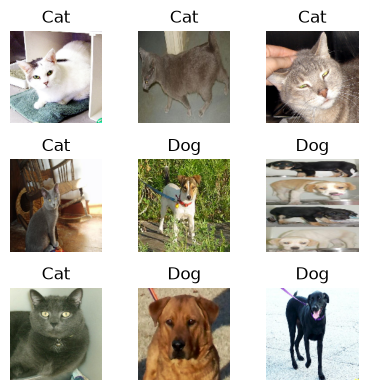

In [6]:
plt.figure(figsize=(4,4))

indices = np.random.choice(len(train_images), 9, replace=False)
for i, idx in enumerate(indices):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[idx].astype(np.uint8))
    plt.title("Dog" if train_labels[idx] else "Cat")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
def build_cnn(input_shape=(150,150,3),
              activation="relu",
              output_activation="sigmoid"):

    model = models.Sequential([
        # Layer 1
        keras.Input(input_shape),
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Layer 2
        layers.Conv2D(64, (3,3), activation=activation),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Layer 3
        layers.Conv2D(128, (3,3), activation=activation),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Fully Connected Layers
        layers.Flatten(),

        # Dense 1
        layers.Dense(256, activation=activation),
        layers.Dropout(0.5),

        # Dense 2 
        layers.Dense(128, activation=activation),
        layers.Dropout(0.5),

        # output
        layers.Dense(1, activation=output_activation)
    ])

    return model

In [8]:
train_images_cnn = train_images.astype("float32") / 255
test_images_cnn = test_images.astype("float32") / 255

train_labels_cnn = train_labels
test_labels_cnn = test_labels

In [9]:
def compile_and_train(model, optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]):
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    history = model.fit(
        train_images_cnn,
        train_labels_cnn,
        epochs=40,
        batch_size=50,
        validation_split=0.2
    )
    return history


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       9,470,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,597,377 (36.61 MB)

 Trainable params: 9,596,929 (36.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.5496 - loss: 3.6108 - val_accuracy: 0.5109 - val_loss: 2.8543
Epoch 2/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5575 - loss: 2.1103 - val_accuracy: 0.5328 - val_loss: 0.8384
Epoch 3/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5739 - loss: 1.4171 - val_accuracy: 0.4984 - val_loss: 1.0055
Epoch 4/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5837 - loss: 1.0771 - val_accuracy: 0.4938 - val_loss: 0.9026
Epoch 5/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5880 - loss: 0.8967 - val_accuracy: 0.5672 - val_loss: 0.6750
Epoch 6/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 51s 979ms/step - accuracy: 0.6001 - loss: 0.7915 - val_accuracy: 0.5328 - val_loss: 0.7193
Epoch 7/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6255 - loss: 0.7251 - val_accuracy: 0.5719 - val_loss: 0.6903
Epoch 8/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 52s 998ms/step - accuracy: 0.6607 - loss: 0.6740 - val_accuracy: 0.6406 - val

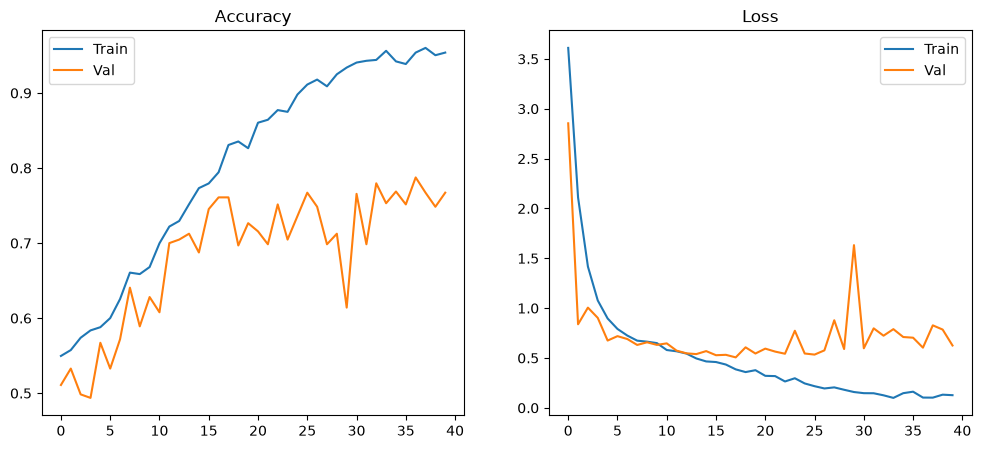

In [10]:
model_cnn = build_cnn()
model_cnn.summary()

history = compile_and_train(model_cnn)
plt.figure(figsize=(12, 5))

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(
    test_images_cnn,
    test_labels_cnn
)
print("Test accuracy:", test_acc_cnn * 100)


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

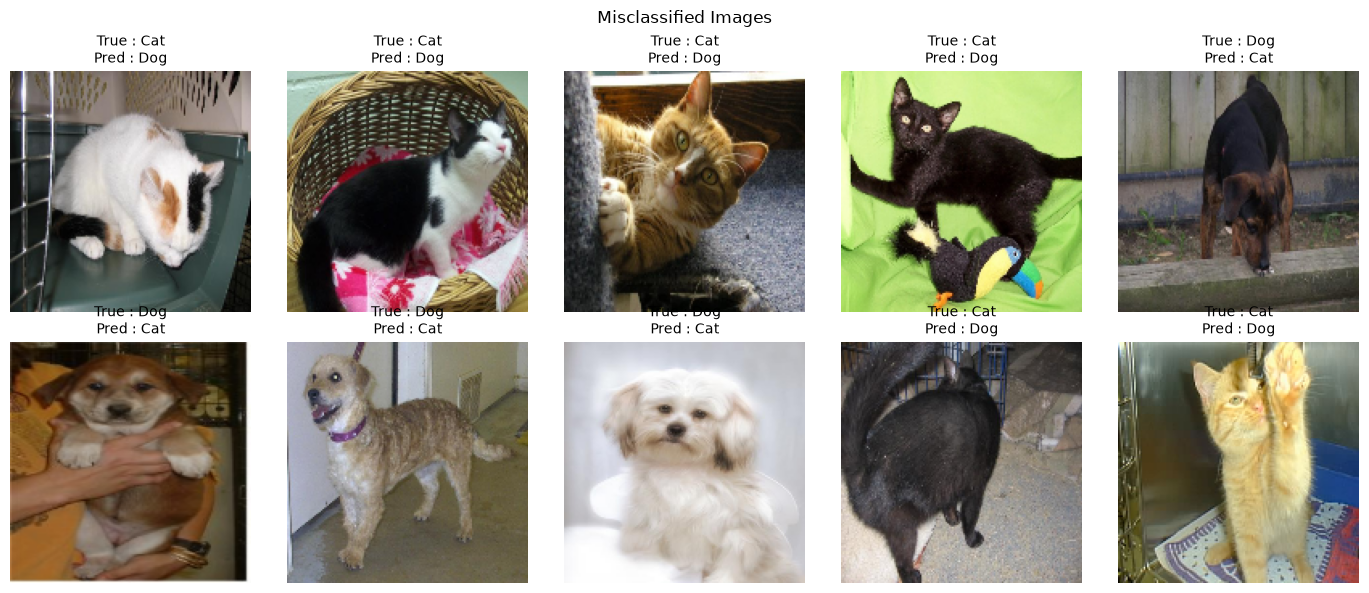

In [11]:
predictions = model_cnn.predict(test_images_cnn, verbose=0)
predicted_labels = (predictions > 0.5).astype(int).ravel()
misclassified_indices = np.where(predicted_labels != test_labels)[0]
plt.figure(figsize=(14,6))
for i, idx in enumerate(misclassified_indices[:10]):

    plt.subplot(2,5,i+1)
    plt.imshow(test_images[idx].astype(np.uint8))
    plt.title(
        f"True : {'Dog' if test_labels[idx] else 'Cat'}\n"
        f"Pred : {'Dog' if predicted_labels[idx] else 'Cat'}",
        fontsize=10 )
    plt.axis("off")
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()

A deep CNN was successfully trained using TensorFlow/Keras, achieving a **test accuracy of over 75%** on the Cats vs Dogs dataset. Compared with the previous fully connected neural networks, the CNN provides a significant improvement by learning spatial features directly from images, demonstrating why convolutional architectures are the standard approach for computer vision tasks.